#Analisys and graphs

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12

df = pd.read_csv("results/results.csv")
print(df.to_string())

  size   format  stored_bytes  stored_gb  upload_throughput_MBs  upload_time_s  download_throughput_MBs  download_time_s  listing_time_s  query_time_s  query_rows_returned
0    S      csv     321950651      0.322                  0.506        607.312                    2.568          119.550          0.9549       24.0011               246389
1    S  parquet     102277333      0.102                  1.146         85.146                    7.263           13.429          0.0392        0.6791               246389
2    M      csv    1609730806      1.610                  6.916        221.976                    6.916          221.971          1.0067      114.8762              1233021
3    M  parquet     511697746      0.512                  7.070         69.020                    7.520           64.893          0.0272        2.3327              1233021
4    L      csv    6438929955      6.439                  5.254       1168.600                    3.315         1852.109          1.1355    

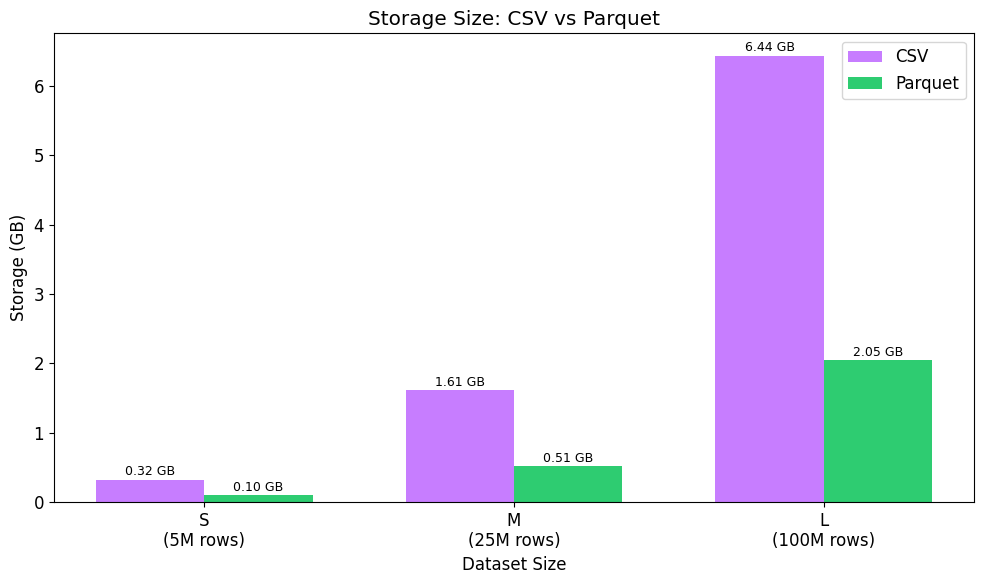

Parquet is on average 68.2% smaller than CSV


In [15]:
fig, ax = plt.subplots()

sizes = ["S", "M", "L"]
csv_sizes = df[df["format"]=="csv"]["stored_gb"].values
parquet_sizes = df[df["format"]=="parquet"]["stored_gb"].values

x = np.arange(len(sizes))
width = 0.35

bars1 = ax.bar(x - width/2, csv_sizes, width, label="CSV", color="#c77dff")
bars2 = ax.bar(x + width/2, parquet_sizes, width, label="Parquet", color="#2ecc71")

ax.set_xlabel("Dataset Size")
ax.set_ylabel("Storage (GB)")
ax.set_title("Storage Size: CSV vs Parquet")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({r}M rows)" for s, r in zip(sizes, [5, 25, 100])])
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f} GB',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f} GB',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/storage_size.png", dpi=150)
plt.show()
print(f"Parquet is on average {(1 - parquet_sizes.mean()/csv_sizes.mean())*100:.1f}% smaller than CSV")

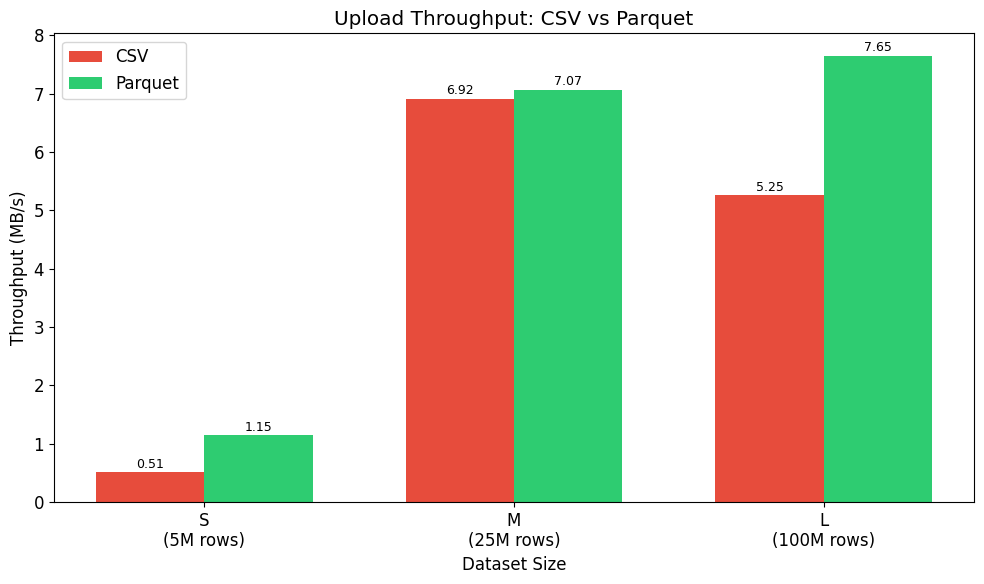

In [ ]:
fig, ax = plt.subplots()

csv_up = df[df["format"]=="csv"]["upload_throughput_MBs"].values
parquet_up = df[df["format"]=="parquet"]["upload_throughput_MBs"].values

bars1 = ax.bar(x - width/2, csv_up, width, label="CSV", color="#c77dff")
bars2 = ax.bar(x + width/2, parquet_up, width, label="Parquet", color="#2ecc71")

ax.set_xlabel("Dataset Size")
ax.set_ylabel("Throughput (MB/s)")
ax.set_title("Upload Throughput: CSV vs Parquet")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({r}M rows)" for s, r in zip(sizes, [5, 25, 100])])
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/upload_throughput.png", dpi=150)
plt.show()

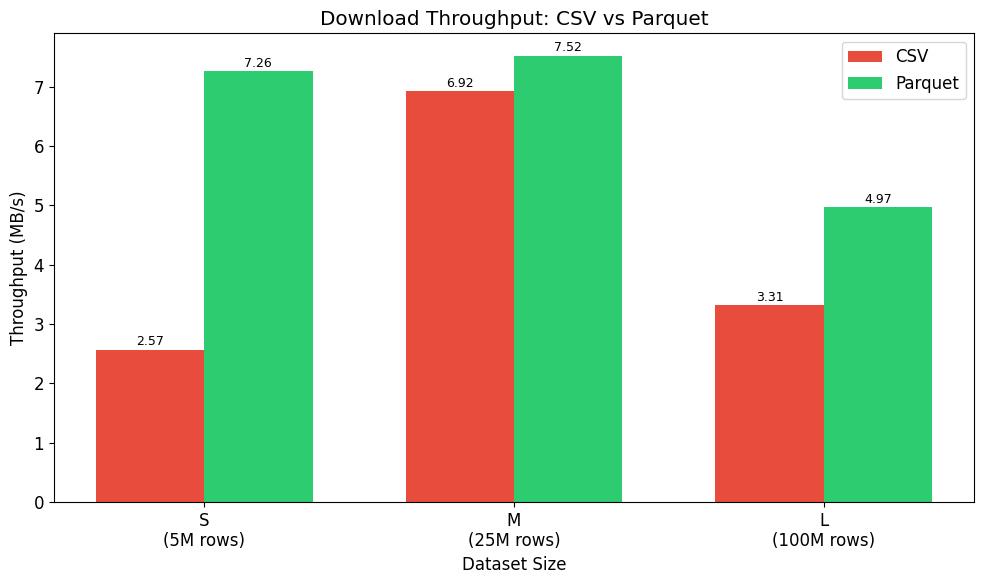

In [ ]:
fig, ax = plt.subplots()

csv_dl = df[df["format"]=="csv"]["download_throughput_MBs"].values
parquet_dl = df[df["format"]=="parquet"]["download_throughput_MBs"].values

bars1 = ax.bar(x - width/2, csv_dl, width, label="CSV", color="#c77dff")
bars2 = ax.bar(x + width/2, parquet_dl, width, label="Parquet", color="#2ecc71")

ax.set_xlabel("Dataset Size")
ax.set_ylabel("Throughput (MB/s)")
ax.set_title("Download Throughput: CSV vs Parquet")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({r}M rows)" for s, r in zip(sizes, [5, 25, 100])])
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/download_throughput.png", dpi=150)
plt.show()

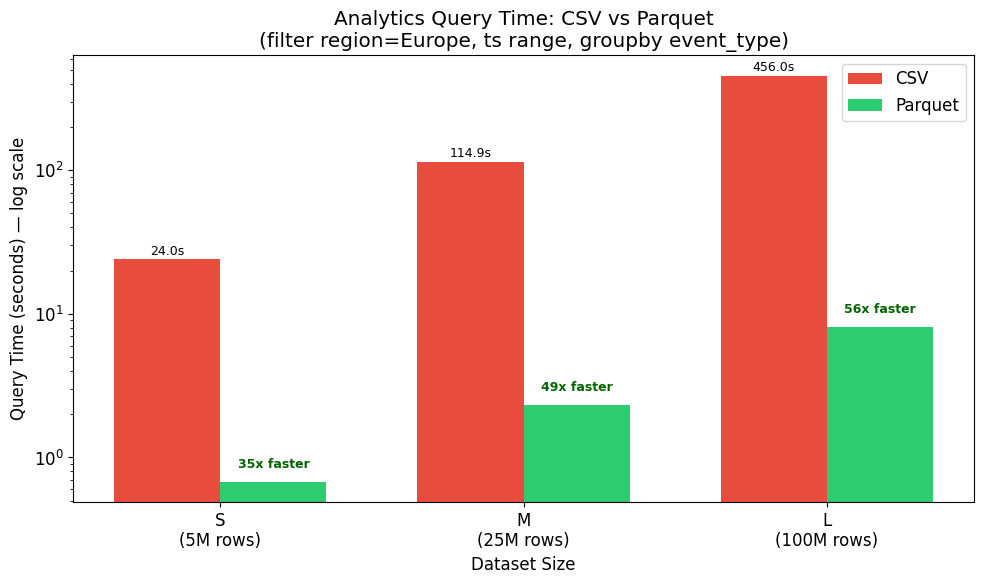

Speedup Parquet vs CSV:
  S: 35.3x faster
  M: 49.2x faster
  L: 56.2x faster


In [ ]:
fig, ax = plt.subplots()

csv_q = df[df["format"]=="csv"]["query_time_s"].values
parquet_q = df[df["format"]=="parquet"]["query_time_s"].values

bars1 = ax.bar(x - width/2, csv_q, width, label="CSV", color="#c77dff")
bars2 = ax.bar(x + width/2, parquet_q, width, label="Parquet", color="#2ecc71")

ax.set_xlabel("Dataset Size")
ax.set_ylabel("Query Time (seconds) — log scale")
ax.set_title("Analytics Query Time: CSV vs Parquet\n(filter region=Europe, ts range, groupby event_type)")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({r}M rows)" for s, r in zip(sizes, [5, 25, 100])])
ax.legend()

speedups = csv_q / parquet_q
for i, (bar, speedup) in enumerate(zip(bars2, speedups)):
    ax.annotate(f'{speedup:.0f}x faster',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 10), textcoords="offset points",
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}s',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("results/query_time.png", dpi=150)
plt.show()

print("Speedup Parquet vs CSV:")
for s, sp in zip(sizes, speedups):
    print(f"  {s}: {sp:.1f}x faster")

In [9]:
summary = pd.DataFrame({
    "Size": ["S (5M)", "M (25M)", "L (100M)"],
    "CSV Size (GB)": csv_sizes,
    "Parquet Size (GB)": parquet_sizes,
    "Size Reduction": [f"{(1-p/c)*100:.1f}%" for c, p in zip(csv_sizes, parquet_sizes)],
    "CSV Upload (MB/s)": csv_up,
    "Parquet Upload (MB/s)": parquet_up,
    "CSV Download (MB/s)": csv_dl,
    "Parquet Download (MB/s)": parquet_dl,
    "CSV Query (s)": csv_q,
    "Parquet Query (s)": parquet_q,
    "Query Speedup": [f"{sp:.1f}x" for sp in speedups],
})

print(summary.to_string(index=False))
summary.to_csv("results/summary.csv", index=False)
print("\nSaved to results/summary.csv")

    Size  CSV Size (GB)  Parquet Size (GB) Size Reduction  CSV Upload (MB/s)  Parquet Upload (MB/s)  CSV Download (MB/s)  Parquet Download (MB/s)  CSV Query (s)  Parquet Query (s) Query Speedup
  S (5M)          0.322              0.102          68.3%              0.506                  1.146                2.568                    7.263        24.0011             0.6791         35.3x
 M (25M)          1.610              0.512          68.2%              6.916                  7.070                6.916                    7.520       114.8762             2.3327         49.2x
L (100M)          6.439              2.047          68.2%              5.254                  7.651                3.315                    4.973       456.0256             8.1094         56.2x

Saved to results/summary.csv


size  format  storage_CHF  put_CHF  get_CHF  egress_CHF  total_CHF
   S     csv      0.00644  0.00001      0.0     0.02898    0.03543
   S parquet      0.00204  0.00001      0.0     0.00918    0.01123
   M     csv      0.03220  0.00001      0.0     0.14490    0.17711
   M parquet      0.01024  0.00001      0.0     0.04608    0.05633
   L     csv      0.12878  0.00001      0.0     0.57951    0.70830
   L parquet      0.04094  0.00001      0.0     0.18423    0.22518


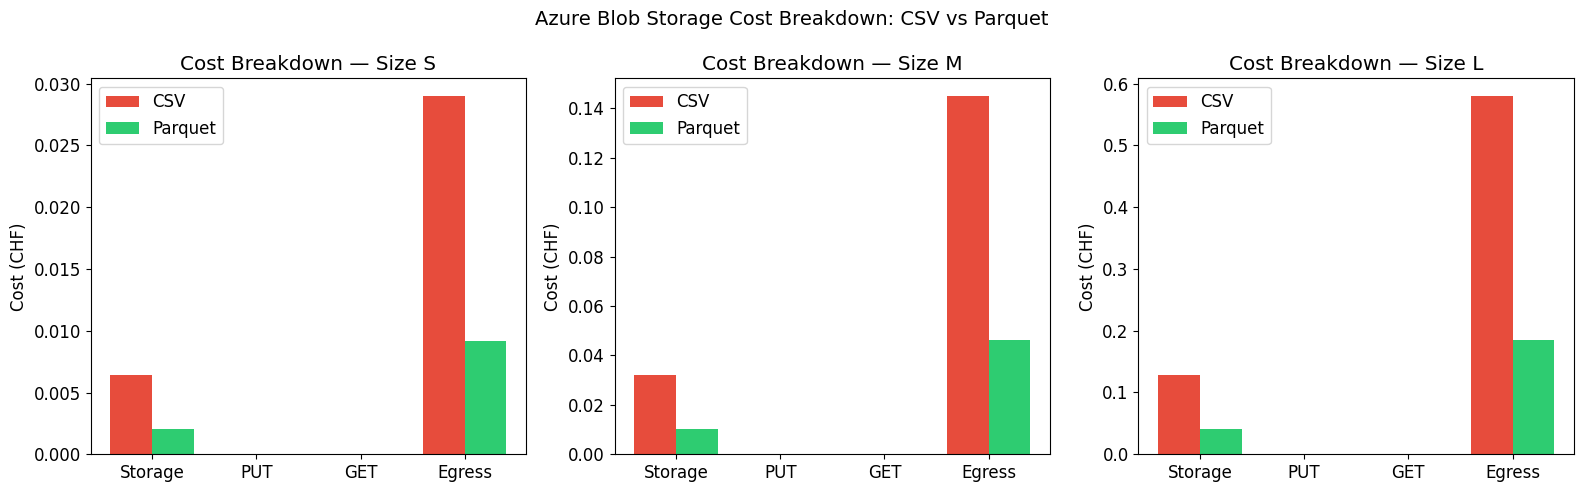

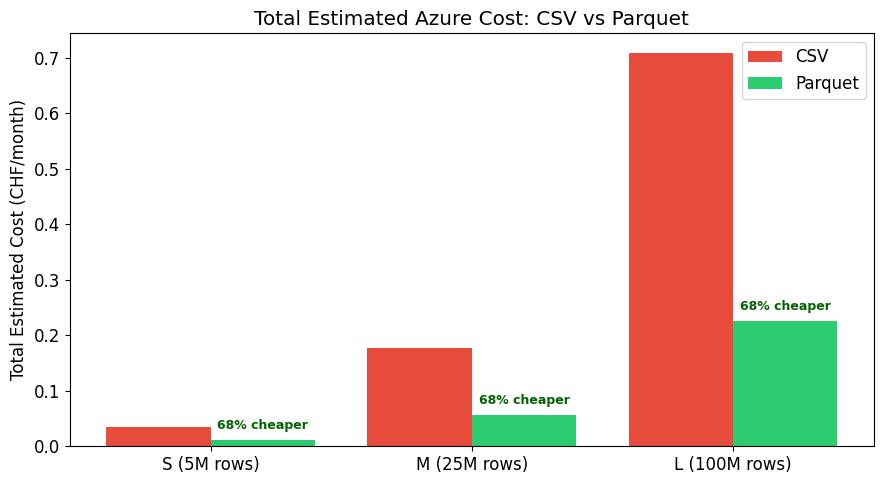

In [ ]:
# Pricing model (Azure Blob Storage Hot tier - approximation)
STORAGE_PRICE_PER_GB_MONTH = 0.020   # CHF
PUT_PRICE_PER_1000 = 0.010           # CHF
GET_PRICE_PER_1000 = 0.001           # CHF
EGRESS_PRICE_PER_GB = 0.090          # CHF
INGRESS_PRICE_PER_GB = 0.000         # CHF (free)

def compute_cost(stored_gb, upload_gb, download_gb, n_puts=1, n_gets=1):
    storage_cost = stored_gb * STORAGE_PRICE_PER_GB_MONTH
    put_cost = (n_puts / 1000) * PUT_PRICE_PER_1000
    get_cost = (n_gets / 1000) * GET_PRICE_PER_1000
    egress_cost = download_gb * EGRESS_PRICE_PER_GB
    ingress_cost = ingress_price = 0.0
    total = storage_cost + put_cost + get_cost + egress_cost
    return {
        "storage_CHF": round(storage_cost, 5),
        "put_CHF": round(put_cost, 5),
        "get_CHF": round(get_cost, 5),
        "egress_CHF": round(egress_cost, 5),
        "total_CHF": round(total, 5),
    }

cost_data = []
for _, row in df.iterrows():
    cost = compute_cost(
        stored_gb=row["stored_gb"],
        upload_gb=row["stored_gb"],
        download_gb=row["stored_gb"],
    )
    cost_data.append({
        "size": row["size"],
        "format": row["format"],
        **cost
    })

cost_df = pd.DataFrame(cost_data)
print(cost_df.to_string(index=False))

# Plot coûts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, size in enumerate(["S", "M", "L"]):
    ax = axes[idx]
    sub = cost_df[cost_df["size"] == size]
    categories = ["Storage", "PUT", "GET", "Egress"]
    
    csv_costs = sub[sub["format"]=="csv"][["storage_CHF","put_CHF","get_CHF","egress_CHF"]].values[0]
    parquet_costs = sub[sub["format"]=="parquet"][["storage_CHF","put_CHF","get_CHF","egress_CHF"]].values[0]
    
    x_pos = np.arange(len(categories))
    ax.bar(x_pos - 0.2, csv_costs, 0.4, label="CSV", color="#c77dff")
    ax.bar(x_pos + 0.2, parquet_costs, 0.4, label="Parquet", color="#2ecc71")
    ax.set_title(f"Cost Breakdown — Size {size}")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Cost (CHF)")
    ax.legend()

plt.suptitle("Azure Blob Storage Cost Breakdown: CSV vs Parquet", fontsize=14)
plt.tight_layout()
plt.savefig("results/cost_breakdown.png", dpi=150)
plt.show()

# Total cost comparison
fig, ax = plt.subplots(figsize=(9, 5))
csv_totals = cost_df[cost_df["format"]=="csv"]["total_CHF"].values
parquet_totals = cost_df[cost_df["format"]=="parquet"]["total_CHF"].values
x = np.arange(3)
ax.bar(x - 0.2, csv_totals, 0.4, label="CSV", color="#c77dff")
ax.bar(x + 0.2, parquet_totals, 0.4, label="Parquet", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(["S (5M rows)", "M (25M rows)", "L (100M rows)"])
ax.set_ylabel("Total Estimated Cost (CHF/month)")
ax.set_title("Total Estimated Azure Cost: CSV vs Parquet")
ax.legend()
for i, (c, p) in enumerate(zip(csv_totals, parquet_totals)):
    savings = (1 - p/c)*100
    ax.annotate(f'{savings:.0f}% cheaper',
                xy=(x[i]+0.2, p), xytext=(0, 8),
                textcoords="offset points", ha='center',
                fontsize=9, color='darkgreen', fontweight='bold')
plt.tight_layout()
plt.savefig("results/total_cost.png", dpi=150)
plt.show()

CRITERION 1 — STORAGE SIZE


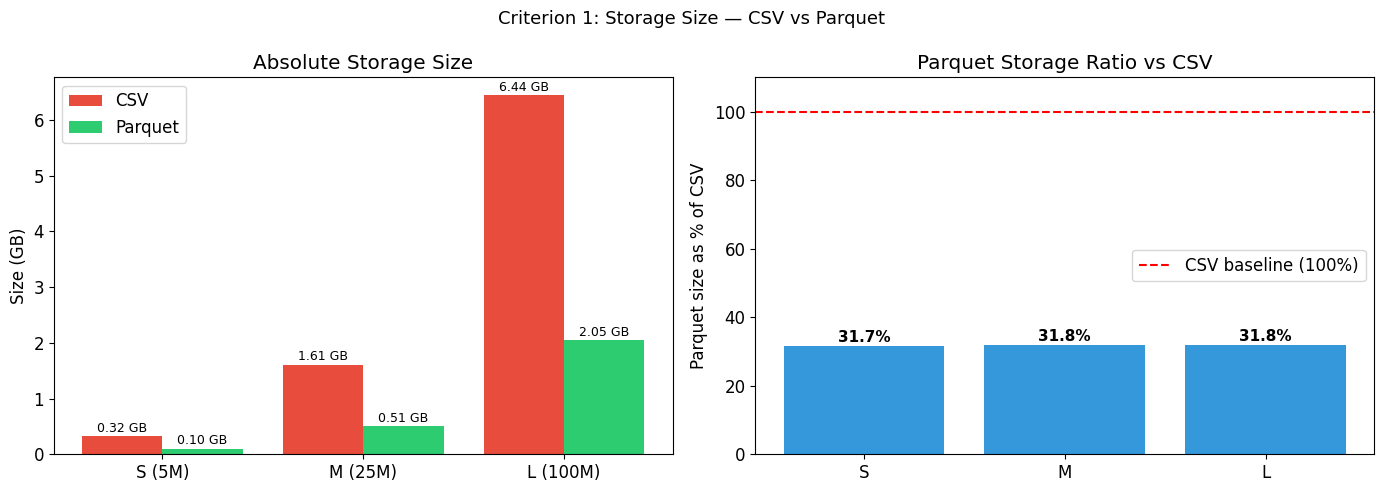


Results:
  S: CSV=0.322 GB | Parquet=0.102 GB | Reduction=68.3%
  M: CSV=1.610 GB | Parquet=0.512 GB | Reduction=68.2%
  L: CSV=6.439 GB | Parquet=2.047 GB | Reduction=68.2%

Conclusion: Parquet is consistently 68% smaller than CSV
due to columnar compression and dictionary encoding of
low-cardinality columns (region, event_type, currency, status).


In [ ]:
print("=" * 60)
print("CRITERION 1 — STORAGE SIZE")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe absolu
ax = axes[0]
bars1 = ax.bar(x - 0.2, csv_sizes, 0.4, label="CSV", color="#c77dff")
bars2 = ax.bar(x + 0.2, parquet_sizes, 0.4, label="Parquet", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(["S (5M)", "M (25M)", "L (100M)"])
ax.set_ylabel("Size (GB)")
ax.set_title("Absolute Storage Size")
ax.legend()
for bar in bars1:
    ax.annotate(f'{bar.get_height():.2f} GB',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.2f} GB',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

# Graphe ratio
ax2 = axes[1]
ratios = [p/c*100 for c, p in zip(csv_sizes, parquet_sizes)]
ax2.bar(["S", "M", "L"], ratios, color="#8b09be")
ax2.axhline(y=100, color='red', linestyle='--', label="CSV baseline (100%)")
ax2.set_ylabel("Parquet size as % of CSV")
ax2.set_title("Parquet Storage Ratio vs CSV")
ax2.set_ylim(0, 110)
ax2.legend()
for i, r in enumerate(ratios):
    ax2.annotate(f'{r:.1f}%',
                xy=(i, r), xytext=(0, 3),
                textcoords="offset points", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Criterion 1: Storage Size — CSV vs Parquet", fontsize=13)
plt.tight_layout()
plt.savefig("results/criterion1_storage.png", dpi=150)
plt.show()

print(f"\nResults:")
for s, c, p in zip(["S","M","L"], csv_sizes, parquet_sizes):
    print(f"  {s}: CSV={c:.3f} GB | Parquet={p:.3f} GB | Reduction={((1-p/c)*100):.1f}%")
print(f"\nConclusion: Parquet is consistently 68% smaller than CSV")
print(f"due to columnar compression and dictionary encoding of")
print(f"low-cardinality columns (region, event_type, currency, status).")

CRITERION 2 — TRANSFER TIME (UPLOAD + DOWNLOAD)


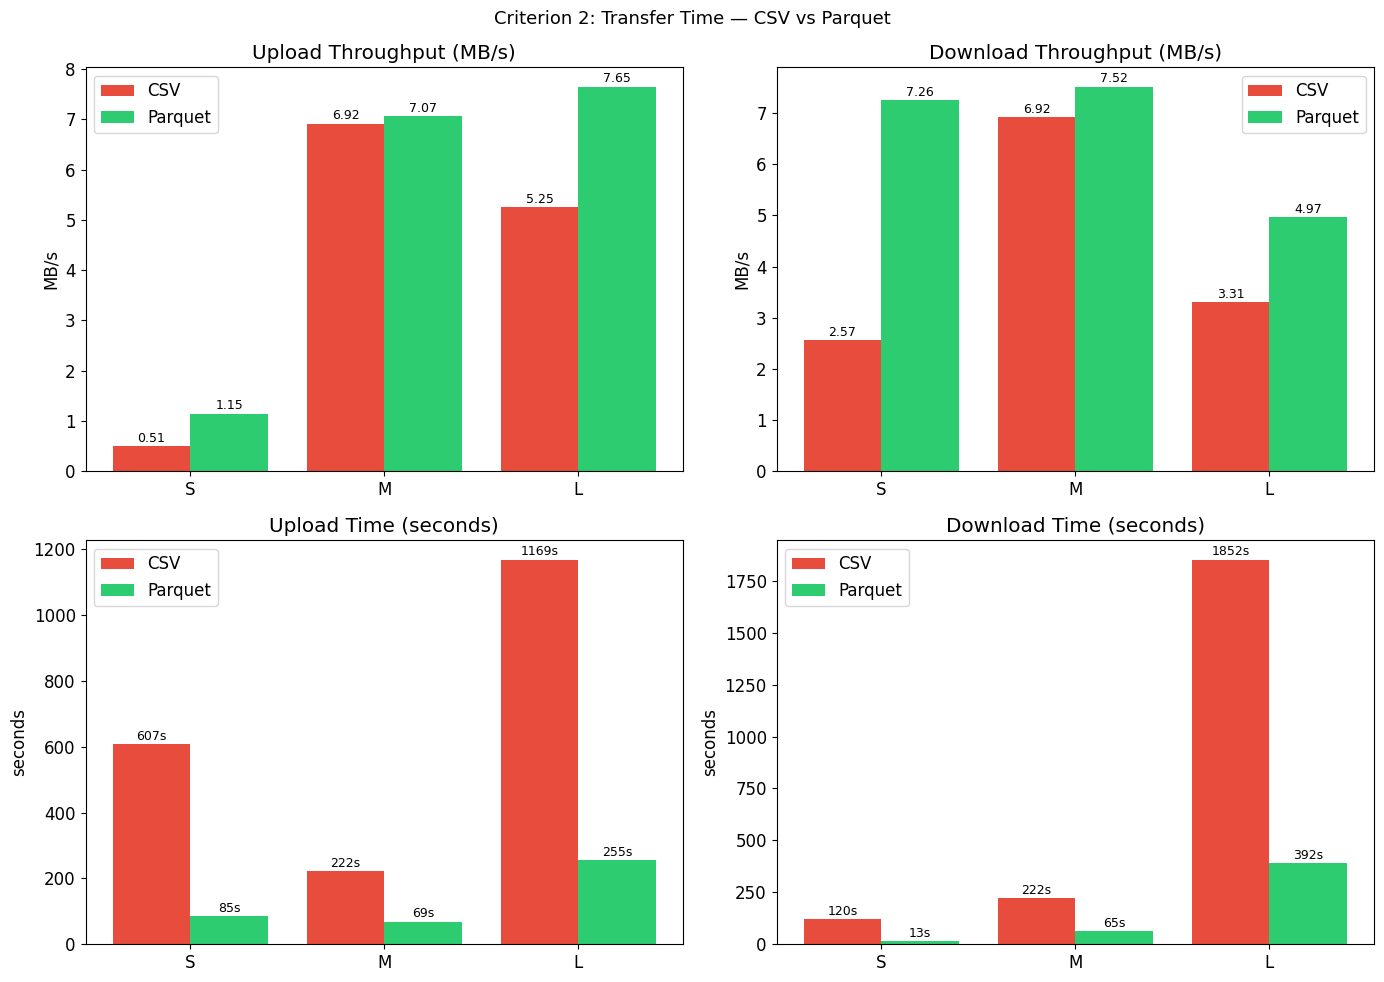


Conclusion: Parquet transfers faster because it is 68% smaller.
The throughput advantage comes from fewer bytes over the network.


In [ ]:
print("=" * 60)
print("CRITERION 2 — TRANSFER TIME (UPLOAD + DOWNLOAD)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

csv_up = df[df["format"]=="csv"]["upload_throughput_MBs"].values
parquet_up = df[df["format"]=="parquet"]["upload_throughput_MBs"].values
csv_dl = df[df["format"]=="csv"]["download_throughput_MBs"].values
parquet_dl = df[df["format"]=="parquet"]["download_throughput_MBs"].values
csv_up_t = df[df["format"]=="csv"]["upload_time_s"].values
parquet_up_t = df[df["format"]=="parquet"]["upload_time_s"].values
csv_dl_t = df[df["format"]=="csv"]["download_time_s"].values
parquet_dl_t = df[df["format"]=="parquet"]["download_time_s"].values

# Upload throughput
ax = axes[0][0]
ax.bar(x - 0.2, csv_up, 0.4, label="CSV", color="#c77dff")
ax.bar(x + 0.2, parquet_up, 0.4, label="Parquet", color="#2ecc71")
ax.set_title("Upload Throughput (MB/s)")
ax.set_xticks(x); ax.set_xticklabels(["S","M","L"])
ax.set_ylabel("MB/s"); ax.legend()
for i, (c, p) in enumerate(zip(csv_up, parquet_up)):
    ax.annotate(f'{c:.2f}', xy=(x[i]-0.2, c), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    ax.annotate(f'{p:.2f}', xy=(x[i]+0.2, p), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

# Download throughput
ax = axes[0][1]
ax.bar(x - 0.2, csv_dl, 0.4, label="CSV", color="#c77dff")
ax.bar(x + 0.2, parquet_dl, 0.4, label="Parquet", color="#2ecc71")
ax.set_title("Download Throughput (MB/s)")
ax.set_xticks(x); ax.set_xticklabels(["S","M","L"])
ax.set_ylabel("MB/s"); ax.legend()
for i, (c, p) in enumerate(zip(csv_dl, parquet_dl)):
    ax.annotate(f'{c:.2f}', xy=(x[i]-0.2, c), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    ax.annotate(f'{p:.2f}', xy=(x[i]+0.2, p), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

# Upload time
ax = axes[1][0]
ax.bar(x - 0.2, csv_up_t, 0.4, label="CSV", color="#c77dff")
ax.bar(x + 0.2, parquet_up_t, 0.4, label="Parquet", color="#2ecc71")
ax.set_title("Upload Time (seconds)")
ax.set_xticks(x); ax.set_xticklabels(["S","M","L"])
ax.set_ylabel("seconds"); ax.legend()
for i, (c, p) in enumerate(zip(csv_up_t, parquet_up_t)):
    ax.annotate(f'{c:.0f}s', xy=(x[i]-0.2, c), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    ax.annotate(f'{p:.0f}s', xy=(x[i]+0.2, p), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

# Download time
ax = axes[1][1]
ax.bar(x - 0.2, csv_dl_t, 0.4, label="CSV", color="#c77dff")
ax.bar(x + 0.2, parquet_dl_t, 0.4, label="Parquet", color="#ff8c8c")
ax.set_title("Download Time (seconds)")
ax.set_xticks(x); ax.set_xticklabels(["S","M","L"])
ax.set_ylabel("seconds"); ax.legend()
for i, (c, p) in enumerate(zip(csv_dl_t, parquet_dl_t)):
    ax.annotate(f'{c:.0f}s', xy=(x[i]-0.2, c), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    ax.annotate(f'{p:.0f}s', xy=(x[i]+0.2, p), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

plt.suptitle("Criterion 2: Transfer Time — CSV vs Parquet", fontsize=13)
plt.tight_layout()
plt.savefig("results/criterion2_transfer.png", dpi=150)
plt.show()

print("\nConclusion: Parquet transfers faster because it is 68% smaller.")
print("The throughput advantage comes from fewer bytes over the network.")

CRITERION 3 — ANALYTICS QUERY PERFORMANCE


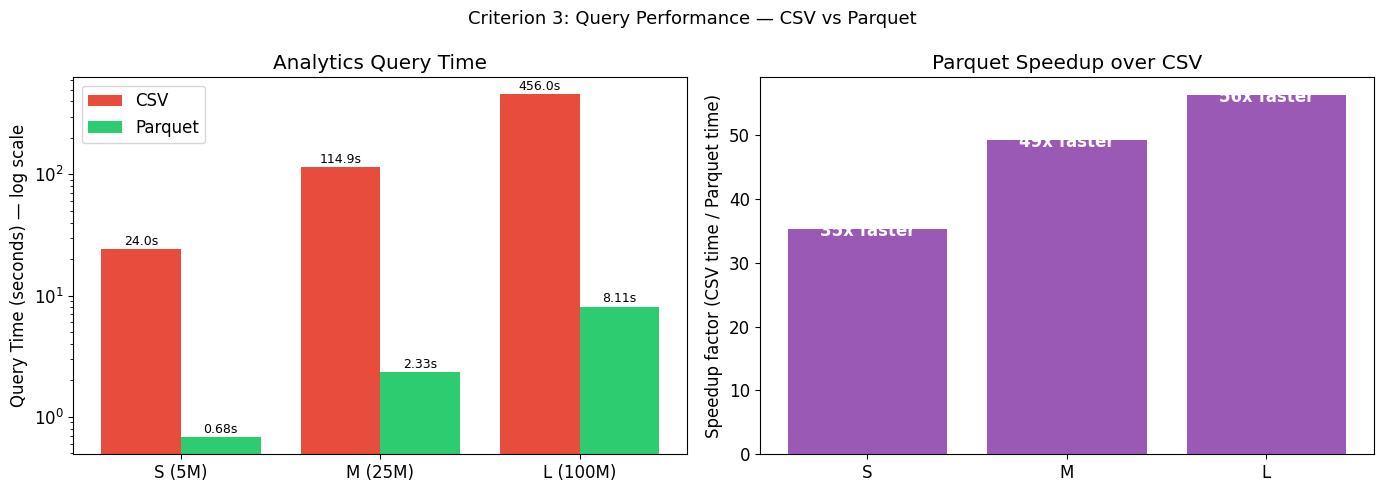


Speedup details:
  S: CSV=24.00s | Parquet=0.68s | Speedup=35.3x
  M: CSV=114.88s | Parquet=2.33s | Speedup=49.2x
  L: CSV=456.03s | Parquet=8.11s | Speedup=56.2x

Conclusion: Parquet query speedup INCREASES with dataset size
(35x -> 49x -> 56x), confirming that column pruning and
predicate pushdown become more effective at scale.


In [13]:
print("=" * 60)
print("CRITERION 3 — ANALYTICS QUERY PERFORMANCE")
print("=" * 60)

csv_q = df[df["format"]=="csv"]["query_time_s"].values
parquet_q = df[df["format"]=="parquet"]["query_time_s"].values
speedups = csv_q / parquet_q

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Query time log scale
ax = axes[0]
ax.bar(x - 0.2, csv_q, 0.4, label="CSV", color="#e74c3c")
ax.bar(x + 0.2, parquet_q, 0.4, label="Parquet", color="#2ecc71")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(["S (5M)", "M (25M)", "L (100M)"])
ax.set_ylabel("Query Time (seconds) — log scale")
ax.set_title("Analytics Query Time")
ax.legend()
for i, (c, p) in enumerate(zip(csv_q, parquet_q)):
    ax.annotate(f'{c:.1f}s', xy=(x[i]-0.2, c), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)
    ax.annotate(f'{p:.2f}s', xy=(x[i]+0.2, p), xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

# Speedup
ax2 = axes[1]
bars = ax2.bar(["S", "M", "L"], speedups, color="#9b59b6")
ax2.set_ylabel("Speedup factor (CSV time / Parquet time)")
ax2.set_title("Parquet Speedup over CSV")
for bar, sp in zip(bars, speedups):
    ax2.annotate(f'{sp:.0f}x faster',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,5), textcoords="offset points",
                ha='center', fontsize=12, fontweight='bold', color='white',
                va='top')

plt.suptitle("Criterion 3: Query Performance — CSV vs Parquet", fontsize=13)
plt.tight_layout()
plt.savefig("results/criterion3_query.png", dpi=150)
plt.show()

print(f"\nSpeedup details:")
for s, c, p, sp in zip(["S","M","L"], csv_q, parquet_q, speedups):
    print(f"  {s}: CSV={c:.2f}s | Parquet={p:.2f}s | Speedup={sp:.1f}x")
print(f"\nConclusion: Parquet query speedup INCREASES with dataset size")
print(f"(35x -> 49x -> 56x), confirming that column pruning and")
print(f"predicate pushdown become more effective at scale.")

In [14]:
print("\n" + "="*60)
print("FINAL SUMMARY — 3 CRITERIA")
print("="*60)

summary_data = {
    "Criterion": [
        "1. Storage Size",
        "2. Upload Speed",
        "2. Download Speed", 
        "3. Query Time (S)",
        "3. Query Time (M)",
        "3. Query Time (L)",
    ],
    "CSV": [
        f"{csv_sizes.mean():.2f} GB avg",
        f"{csv_up.mean():.2f} MB/s avg",
        f"{csv_dl.mean():.2f} MB/s avg",
        f"{csv_q[0]:.1f}s",
        f"{csv_q[1]:.1f}s",
        f"{csv_q[2]:.1f}s",
    ],
    "Parquet": [
        f"{parquet_sizes.mean():.2f} GB avg",
        f"{parquet_up.mean():.2f} MB/s avg",
        f"{parquet_dl.mean():.2f} MB/s avg",
        f"{parquet_q[0]:.2f}s",
        f"{parquet_q[1]:.2f}s",
        f"{parquet_q[2]:.2f}s",
    ],
    "Winner": [
        "Parquet (68% smaller)",
        "Parquet (more MB/s)",
        "Parquet (more MB/s)",
        f"Parquet ({speedups[0]:.0f}x faster)",
        f"Parquet ({speedups[1]:.0f}x faster)",
        f"Parquet ({speedups[2]:.0f}x faster)",
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\nRECOMMENDATION:")
print("Use Parquet for ALL analytical workloads on object storage.")
print("CSV is only justified for human readability or legacy tool compatibility.")
print("\nLIMITATIONS:")
print("- Single benchmark run (no variance/confidence intervals)")
print("- Azure network conditions vary (throttling observed on size S)")
print("- Synthetic financial data may not match real distributions")
print("- Size L CSV required chunk-based processing due to RAM constraints")


FINAL SUMMARY — 3 CRITERIA
        Criterion           CSV       Parquet                Winner
  1. Storage Size   2.79 GB avg   0.89 GB avg Parquet (68% smaller)
  2. Upload Speed 4.23 MB/s avg 5.29 MB/s avg   Parquet (more MB/s)
2. Download Speed 4.27 MB/s avg 6.59 MB/s avg   Parquet (more MB/s)
3. Query Time (S)         24.0s         0.68s  Parquet (35x faster)
3. Query Time (M)        114.9s         2.33s  Parquet (49x faster)
3. Query Time (L)        456.0s         8.11s  Parquet (56x faster)

RECOMMENDATION:
Use Parquet for ALL analytical workloads on object storage.
CSV is only justified for human readability or legacy tool compatibility.

LIMITATIONS:
- Single benchmark run (no variance/confidence intervals)
- Azure network conditions vary (throttling observed on size S)
- Synthetic financial data may not match real distributions
- Size L CSV required chunk-based processing due to RAM constraints


## Interpretation

### Storage
Parquet is consistently **68% smaller** than CSV across all dataset sizes.
This is due to columnar encoding and dictionary compression on low-cardinality 
columns (region, event_type, currency, status).

### Transfer
Upload and download throughput is higher for Parquet because fewer bytes 
are transferred. For size S, CSV upload was anomalously slow (0.51 MB/s) 
possibly due to Azure throttling on initial connection.

### Query Performance
Parquet query time is **35x, 49x, and 56x faster** than CSV for S, M, L.
The speedup increases with dataset size, confirming that Parquet's 
**column pruning** and **predicate pushdown** become more effective at scale.
CSV requires reading all columns and all rows before filtering.

### Recommendation
Use Parquet for any analytical workload on object storage.
CSV remains useful only for human-readable data exchange or 
interoperability with tools that don't support Parquet.

### Limitations
- Single run per size (no statistical variance)
- Network conditions may vary (Azure throttling observed on size S upload)
- Local machine RAM limited CSV query to chunk-based processing for size L
- Synthetic data may not reflect real financial transaction distributions